## 教程六：SA‑QITE 算法 —— 基于随机逼近的变分量子虚时演化

在前面的教程中，我们学习了 **VarQITE、RMITE、SSQITE** 算法，其中**RMITE算法**在**VarQITE 算法**的基础上实现了计算复杂度的降低。然而，当参数规模 $m$ 达到数百以上时，即使 $O(m)$ 的成本也可能很大。SA‑QITE (Stochastic Approximation QITE) 算法利用 SPSA 二阶随机逼近，将 QFIM 的估计成本降至 常数级，再通过多次采样和动量平滑逼近真实 QFIM，使每步总成本为 $O(N)$，$N$ 为采样次数（通常 10–100），从而做到计算复杂度与参数维度 $m$ 完全无关。  
以下我们就来学习 **SA‑QITE算法**。

### 1. SPSA 回顾：从梯度到海森矩阵的随机逼近
#### 1.1 一阶 SPSA（梯度估计）
对于目标函数 $f(\boldsymbol{\theta}):\mathbb{R}^d\to\mathbb{R},$ 一阶 SPSA 使用单一随机方 $\boldsymbol{\Delta}\sim\mathcal{U}(\{+1,-1\}^d)$ 估计梯度：
$$ \hat{\nabla}f(\boldsymbol{\theta})=\frac{f(\boldsymbol{\theta}+\epsilon\boldsymbol{\Delta})-f(\boldsymbol{\theta}-\epsilon\boldsymbol{\Delta})}{2\epsilon}\cdot\boldsymbol{\Delta}$$
其中 $\epsilon>0$ 是小扰动。该估计是无偏的，且仅需 2 次 函数评估，与维数 $d$ 无关。  

#### 1.2 二阶 SPSA（Hessian / QFIM 估计）
为了估计海森矩阵或 QFIM，我们需要两个独立的随机方向 $\Delta_1,\Delta_2\sim\mathcal{U}(\{+1,-1\}^d)$ 。四点差分公式为：
$$ \delta F=F(\boldsymbol{\theta}+\epsilon(\boldsymbol{\Delta}_{1}+\boldsymbol{\Delta}_{2}))-F(\boldsymbol{\theta}+\epsilon(\boldsymbol{\Delta}_{1}-\boldsymbol{\Delta}_{2}))-F(\boldsymbol{\theta}-\epsilon(\boldsymbol{\Delta}_{1}-\boldsymbol{\Delta}_{2}))+F(\boldsymbol{\theta}-\epsilon(\boldsymbol{\Delta}_{1}+\boldsymbol{\Delta}_{2}))$$
其中 $F$ 是待求二阶导数的函数（在 QFIM 情形中为保真度）。则 Hessian 的无偏样本为：
$$ \hat{H}=\frac{\delta F}{8\epsilon^2}\cdot\frac{\boldsymbol{\Delta}_1\boldsymbol{\Delta}_2^\top+\boldsymbol{\Delta}_2\boldsymbol{\Delta}_1^\top}{2}$$
该样本的期望等于真实 Hessian，且只需 4 次 函数评估。

### 2. SA‑QITE 的数学形式
#### 2.1 虚时演化与 QGT
VarQITE 基于 McLachlan 变分原理，要求参数满足：
$$ g(\boldsymbol{\theta})\dot{\boldsymbol{\theta}}=\boldsymbol{b}(\boldsymbol{\theta})$$
其中 $g\in\mathbb{R}^{d\times d}$ 是量子几何张量 (QGT) 的实部，即量子 Fisher 信息矩阵 (QFIM) 的 1/4 倍；  
$\boldsymbol{b}\in\mathbb{R}^d$ 是能量梯度：
$$ b_{i}=-\frac{1}{2}\frac{\partial E}{\partial\theta_{i}}=-\mathrm{Re}\left\langle\frac{\partial\phi}{\partial\theta_{i}}{\left|H\right|}\phi\right\rangle$$
而 量子几何张量（QGT） 可表示为 Fubini‑Study 度量的 Hessian：
$$ g_{ij}(\boldsymbol{\theta})=-\frac{1}{2}\left.\frac{\partial^{2}}{\partial\theta_{i}\partial\theta_{j}}|\langle\phi(\boldsymbol{\theta}^{\prime})|\phi(\boldsymbol{\theta})\rangle|^{2}\right|_{\boldsymbol{\theta}^{\prime}=\boldsymbol{\theta}}$$
这一形式使得我们可以直接应用二阶 SPSA：只需将上述公式中的函数 $F$ 替换为保真度 $F(\boldsymbol{\theta},\boldsymbol{\omega})=|\langle\phi(\boldsymbol{\theta})|\phi(\boldsymbol{\omega})\rangle|^{2}$

#### 2.2 单样本 QGT 估计
固定当前参数 $θ$ ，抽取两个独立的随机方向 $\mathbf{\Delta}_1,\mathbf{\Delta}_2$ ,定义
$$ \delta F=F(\boldsymbol{\theta},\boldsymbol{\theta}+\epsilon(\boldsymbol{\Delta}_1+\boldsymbol{\Delta}_2))-F(\boldsymbol{\theta},\boldsymbol{\theta}+\epsilon(\boldsymbol{\Delta}_1-\boldsymbol{\Delta}_2))-F(\boldsymbol{\theta},\boldsymbol{\theta}+\epsilon(\boldsymbol{\Delta}_2-\boldsymbol{\Delta}_1))+F(\boldsymbol{\theta},\boldsymbol{\theta}-\epsilon(\boldsymbol{\Delta}_1+\boldsymbol{\Delta}_2))$$

则 QGT 的无偏样本为：
$$ \hat{g}=-\frac{1}{2}\cdot\frac{\delta F}{4\epsilon^{2}}\cdot\frac{\mathbf{\Delta}_{1}\mathbf{\Delta}_{2}^{\top}+\mathbf{\Delta}_{2}\mathbf{\Delta}_{1}^{\top}}{2}=-\frac{\delta F}{16\epsilon^{2}}\left(\mathbf{\Delta}_{1}\mathbf{\Delta}_{2}^{\top}+\mathbf{\Delta}_{2}\mathbf{\Delta}_{1}^{\top}\right)$$
注意到该样本是对称、秩最多为 2 的矩阵。单个样本无法覆盖全部 $d×d$ 耦合信息，因此需要多次采样平均。

#### 2.3 单样本梯度估计
使用一阶 SPSA 估计能量梯度：
$$ \hat{\boldsymbol{b}}=-\frac{1}{2}\cdot\frac{E(\boldsymbol{\theta}+\epsilon\boldsymbol{\Delta})-E(\boldsymbol{\theta}-\epsilon\boldsymbol{\Delta})}{2\epsilon}\cdot\boldsymbol{\Delta}=-\frac{E(\boldsymbol{\theta}+\epsilon\boldsymbol{\Delta})-E(\boldsymbol{\theta}-\epsilon\boldsymbol{\Delta})}{4\epsilon}\boldsymbol{\Delta}$$

### 3. 改进估计器：动量更新与精确初始化
#### 3.1 批平均与动量
在每步迭代 $k$ 中，抽取 $N$ 个独立样本 $\{\hat{g}_i^{(k)}\}_{i=1}^N\text{和}\{\hat{\boldsymbol{b}}_i^{(k)}\}_{i=1}^N$ ,计算批平均：
$$ \bar{g}_N^{(k)}=\frac{1}{N}\sum_{i=1}^N\hat{g}_i^{(k)},\quad\bar{\boldsymbol{b}}_N^{(k)}=\frac{1}{N}\sum_{i=1}^N\hat{\boldsymbol{b}}_i^{(k)}$$
然后与历史估计进行指数平滑（动量更新）：
$$ \bar{g}^{(k)}=\tau_1\bar{g}^{(k-1)}+(1-\tau_1)\bar{g}_N^{(k)},\quad\bar{\boldsymbol{b}}^{(k)}=\tau_2\bar{\boldsymbol{b}}^{(k-1)}+(1-\tau_2)\bar{\boldsymbol{b}}_N^{(k)}$$
动量系数 $\tau_1,\tau_2\in(0,1)$ 控制历史信息的保留程度。对于时间演化，通常取 $\tau_1$ 接近 1，而 $\tau_2=0$ 以避免梯度动量引入偏差。

#### 3.2 精确初始化的重要性
由于动量引入偏差，初始估计 $\bar{g}^{(0)}$ 和 $\bar{b}^{(0)}$ 需要足够准确。参考文献[1] 建议：  
若初始参数对应 Clifford 电路，则 QGT 和梯度可通过经典 Clifford 模拟高效精确计算。在优化问题中（如 QAOA 初始为零参数），电路也是 Clifford，因此可以直接获得精确初始值。  

### 4. 代码演示

#### 4.1 导入必要的库

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  # 如果 notebook 在 examples/ 下
sys.path.insert(0, PROJECT_ROOT)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from hyq.backends.Tensorcircuit import TensorCircuitBackend
from hyq.ansatz.HEA import HEAAnsatz
from hyq.solvers.sa_qite import SAQITESolver

Please first ``pip install -U qiskit`` to enable related functionality in translation module


#### 4.2 定义哈密顿量
我们选择的两比特 Ising 模型哈密顿量为：
$$H=1.0\cdot ZZ-1.0\cdot XI-1.0\cdot IX$$
其精确基态能量已知约为 -2.23。我们将使用此哈密顿量测试 SA‑QITE 的基态逼近能力。

In [3]:
hamiltonian = [(1.0, 'ZZ'), (-1.0, 'XI'), (-1.0, 'IX')]

#### 4.3 初始化量子后端与参数化电路
我们使用硬件高效拟设（HEA），量子比特数 **n_qubits=2**，深度 **depth=3**。该电路有 **n_qubits * (depth+1) = 8** 个参数。

In [4]:
backend = TensorCircuitBackend()
n_qubits = 2
depth = 3
ansatz = HEAAnsatz(n_qubits=n_qubits, depth=depth)

# 随机初始化参数（范围 [0, 2π)）
init_params = torch.rand(ansatz.num_parameters, dtype=torch.float64) * 2 * np.pi
print(f"参数数量: {ansatz.num_parameters}")

参数数量: 8


#### 4.4 配置 SA‑QITE 求解器参数
SA‑QITE 的核心参数如下：  
**total_tau**：总虚时演化长度   
**delta_tau**：数值积分步长  
**n_samples**：每步采样次数 $N$。每个迭代步中用于平均的独立 SPSA 样本数；增大可降低方差  
**epsilon**: 扰动幅度。SPSA 有限差分中的 $ϵ$，影响梯度/QGT 近似精度  
**tau1**: QGT 动量系数。对应指数平滑中的 $\tau_{1}$ ,用于平滑 QGT 估计  
**tau2**: 梯度动量系数。一般设为 0，避免引入偏差  
**delta**：稳定子空间阈值。用于求解线性系统时丢弃小特征值分量，防止数值不稳定


In [5]:
solver = SAQITESolver(backend)

final_energy, final_params, energies, _ = solver.solve(
    ansatz,
    init_params,
    hamiltonian,
    total_tau=5.0,
    delta_tau=0.2,
    n_samples=30,      # 每步 30 个样本
    epsilon=0.05,
    tau1=0.95,
    tau2=0.0,
    delta=0.1
)

print(f"最终能量: {final_energy:.6f}")

--- SA-QITE Start (N=30, Total Tau=5.0) ---
SA-QITE Step 0: Energy = 1.106237 (Time: 1.0930s)
SA-QITE Step 5: Energy = -2.231497 (Time: 1.0699s)
SA-QITE Step 10: Energy = -2.236058 (Time: 1.0380s)
SA-QITE Step 15: Energy = -2.236028 (Time: 1.1010s)
SA-QITE Step 20: Energy = -2.236042 (Time: 1.1139s)
SA-QITE Step 24: Energy = -2.235992 (Time: 1.0650s)
最终能量: -2.235992


#### 4.5 可视化能量收敛曲线

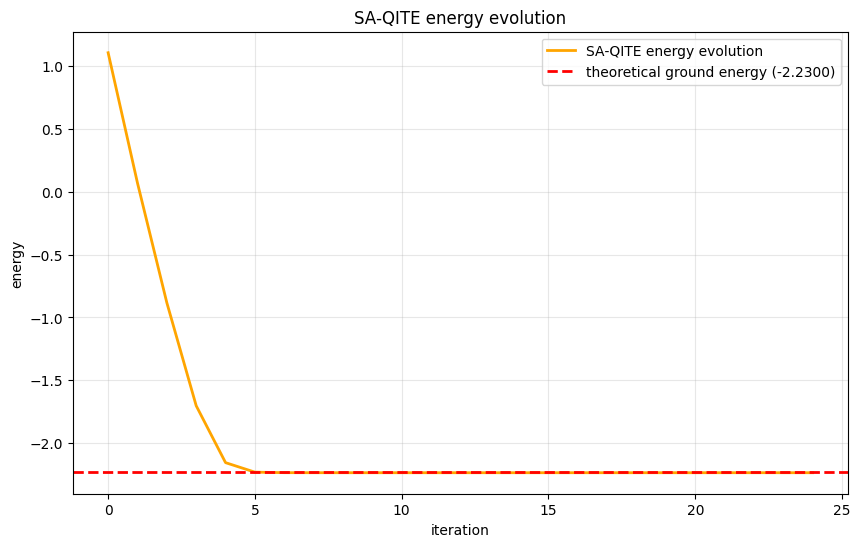

In [8]:
# 理论基态能量
theoretical_ground = -2.23  

plt.figure(figsize=(10, 6))
plt.plot(energies, label='SA‑QITE energy evolution', color='orange', linewidth=2)
plt.axhline(y=theoretical_ground, color='red', linestyle='--',
            label=f'theoretical ground energy ({theoretical_ground:.4f})', linewidth=2)
plt.xlabel('iteration')
plt.ylabel('energy')
plt.title('SA‑QITE energy evolution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5. 结果讨论
从图中可以看到，SA‑QITE 的能量从初始随机值逐渐下降，最终逼近理论基态附近。通过本实例，读者可以直观理解 SA‑QITE 的实践流程，并掌握关键超参数对收敛行为的影响。接下来的实验可以尝试调整 **n_samples、tau1** 等参数，观察能量曲线波动的变化，进一步加深对随机逼近方法的理解。

### 6.参考文献
[1] Gacon, J., Zoufal, C., Carleo, G., & Woerner, S. (2021). Simultaneous Perturbation Stochastic Approximation of the Quantum Fisher Information. Quantum.  
[2] Gacon, J., Zoufal, C., Carleo, G., & Woerner, S. (2023). Stochastic Approximation of Variational Quantum Imaginary Time Evolution. 2023 IEEE International Conference on Quantum Computing and Engineering (QCE).